# Dynamika zawodników defensywnych podczas meczu piłki nożnej. Optymalizacja ustawienia

Odkąd w Cambridge w 1848 roku zapisano pierwsze zasady piłki nożnej, gra nieustannie ewoluuje. Początkowo najpopularniejszą formacją była tak zwana „odwrócona piramida”, czyli ustawienie 1-2-3-5. Dopiero później uświadomiono sobie, że dwóch środkowych obrońców to zdecydowanie za mało, i dziś w formacji obronnej widujemy trzech, czterech, a nawet pięciu obrońców. Jeden z najlepszych menedżerów w piłce nożnej, Sir Alex Ferguson, powiedział: „Atak wygrywa ci mecze, obrona wygrywa ci trofea” – i jest w tym wiele prawdy. Aby wygrać mecz, zazwyczaj musisz zdobyć jedną bramkę więcej niż przeciwnik, a staje się to o wiele łatwiejsze, gdy twoja defensywa jest szczelna.

Na zachowanie obrońcy wpływa wiele czynników, ale my skupimy się głównie na trzech z nich: wyznaczonej pozycji, odległości od przeciwnika oraz odległości od kolegów z drużyny. W naszym projekcie postaramy się znaleźć optymalne zachowanie obrońców za pomocą równania różniczkowego i zdecydować, jaka mieszanka tych czynników przynosi najlepsze rezultaty w obronie własnej bramki. Oczywiście tak uproszczony model nie rozwiąże problemów menedżerów największych klubów piłkarskich, ale może okazać się pomocny przy planowaniu treningów czy tworzeniu piłkarskich gier komputerowych.

---

## Wzór na całkowitą siłę działającą na zawodnika

Równanie opisujące całkowitą siłę działającą na $i$-tego zawodnika w drużynie można zapisać jako:

$$
\frac{d \mathbf{r}_{i}}{dt} = \mathbf{F}_{\text{pos},i} + \mathbf{F}_{\text{opp},i} + \mathbf{F}_{\text{team},i}
$$

### Gdzie:
- $\mathbf{r}_i(t)$: Pozycja $i$-tego obrońcy w czasie $t$ jako wektor $[\mathbf{x}_i(t), \mathbf{y}_i(t)]$,
- $\frac{d\mathbf{r}_i}{dt}$: Prędkość $i$-tego obrońcy (zmiana pozycji w czasie),
- $\mathbf{F}_{\text{pos},i}$: Siła przyciągania $i$-tego obrońcy do ustalonej pozycji na boisku,
- $\mathbf{F}_{\text{opp},i}$: Siła działająca na $i$-tego obrońcę reagująca na przeciwnika z piłką,
- $\mathbf{F}_{\text{team},i}$: Siła działająca na $i$-tego obrońcę reagująca na pozycję kolegów z drużyny.

Zgodnie z zasadą superpozycji w mechanice klasycznej, siły pochodzące z różnych źródeł mogą być sumowane w celu wyznaczenia całkowitej siły działającej na ciało.

---

## 1. Siła dążenia do pozycji ($F_{\text{pos}, i}$)

Siła ta opisuje dążenie zawodnika do swojej wyznaczonej pozycji na boisku. Bazuje ona na **prawie Hooke’a** (siła sprężystości): $F = -k \cdot x$.

$$
F_{\text{pos}, i} = -k_{\text{pos}} \cdot (\mathbf{r}_i - \mathbf{r}_{\text{pos}, i})
$$

Gdzie:
- $\mathbf{r}_i$: Aktualna pozycja $i$-tego zawodnika,
- $\mathbf{r}_{\text{pos}, i}$: Wyznaczona pozycja $i$-tego zawodnika,
- $k_{\text{pos}}$: Współczynnik określający intensywność dążenia do celu.

---

## 2. Siła przyciągania do przeciwnika ($F_{\text{opp}, i}$)

Siła ta opisuje reakcję zawodnika na pozycję przeciwnika. Bazuje ona na **prawie grawitacji** (przyciąganie ciał):

$$
F_{\text{opp}, i} = \frac{k_{\text{opp}} \cdot (\mathbf{r}_{\text{opp}} - \mathbf{r}_i)}{\|\mathbf{r}_{\text{opp}} - \mathbf{r}_i\|^2 + \epsilon}
$$

Gdzie:
- $\mathbf{r}_{\text{opp}}$: Pozycja przeciwnika z piłką,
- $\mathbf{r}_i$: Aktualna pozycja $i$-tego zawodnika,
- $k_{\text{opp}}$: Współczynnik określający intensywność reakcji na przeciwnika,
- $\epsilon$: Mała wartość dodana w celu uniknięcia dzielenia przez zero.

W naszym modelu zawodnik $i$ jest przyciągany przez przeciwnika w punkcie $\mathbf{r}_{\text{opp}}$, a siła maleje z kwadratem odległości ($\|\mathbf{r}_{\text{opp}} - \mathbf{r}_i\|^2$). Współczynnik $k_{\text{opp}}$ kontroluje, jak silne jest przyciąganie, a $\varepsilon$ zapobiega dzieleniu przez zero, gdy zawodnik $i$ znajduje się bardzo blisko przeciwnika.

---

## 3. Siła odpychania od kolegów z drużyny ($F_{\text{team}, i}$)

Siła ta opisuje interakcje przestrzenne zawodnika z innymi członkami drużyny. Bazuje ona na **prawie Coulomba** (odpychanie między ładunkami): $F \sim \frac{1}{r^2}$.

$$
F_{\text{team}, i} = \sum_{j \neq i} \frac{-k_{\text{team}} \cdot (\mathbf{r}_j - \mathbf{r}_i)}{\|\mathbf{r}_j - \mathbf{r}_i\|^2 + \epsilon}
$$

Gdzie:
- $\mathbf{r}_j$: Pozycja $j$-tego kolegi z drużyny,
- $\mathbf{r}_i$: Aktualna pozycja $i$-tego zawodnika,
- $k_{\text{team}}$: Współczynnik określający intensywność odpychania,
- $\epsilon$: Mała wartość dodana w celu uniknięcia dzielenia przez zero.

Ten składnik inspirowany jest zjawiskiem "odpychania", podobnym do sił między naładowanymi cząstkami w modelu elektrostatycznym, gdzie zawodnicy unikają nadmiernego tłoku wokół siebie.

---

## Podobieństwo do algorytmu stada (Boids)

Stworzony przez nas wzór jest bardzo podobny do algorytmu **Boids**, opracowanego przez Craiga Reynoldsa w 1986 roku, który służy do symulowania zachowań grupy autonomicznych agentów (np. ptaków, ryb, owadów) poruszających się w przestrzeni na podstawie trzech prostych zasad: separacji, wyrównania i kohezji. Zasady te w pewnym sensie odpowiadają naszym zasadom ruchu.

- **Separacja** w Boids zapobiega zderzeniom między agentami, co w naszym przypadku odpowiada sile $F_{\text{team}, i}$, która utrzymuje odpowiednią odległość między obrońcami, zapobiegając zbytnim skupiskom.
- **Wyrównanie** powoduje, że boidy dążą do wyrównania swoich prędkości – ten aspekt nie ma odzwierciedlenia w naszym modelu.
- **Kohezja** zapewnia spójność grupy, co w naszym modelu odpowiada równowadze między siłami $F_{\text{pos}, i}$ i $F_{\text{opp}, i}$, które pomagają obrońcom reagować na ruchy przeciwnika, jednocześnie utrzymując pozycje w drużynie.

---

## Symulacja ataku na bramkę

Korzystając z naszego wzoru przygotowaliśmy prostą symulację obrony akcji bramkowej. Napastnicy przemieszczają się w linii prostej w stronę pola karnego, a zachowanie obrońców jest wynikową sumy naszych sił działających na nich. Gdy dochodzi do spotkania defensora i atakującego z piłką, z prawdopodobieństwem do 50% (w zależności od odległości miedzy zawodnikami) piłka zostaje odebrana, co kończy symulację na korzyść drużyny broniącej. Alternatywnie, napastnik podaje piłkę do najbliższego kolegi z drużyny, który jest w bezpiecznej pozycji. Zwycięstwem drużyny atakującej jest dotarcie do pola karnego przeciwnika.

---




In [3]:
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

FORCE_EPSILON = 0.5
MAX_FORCE = 8.0
FIELD_X_MIN, FIELD_X_MAX = 0.0, 68.0
FIELD_Y_MIN, FIELD_Y_MAX = 0.0, 105.0
PENALTY_BOX_Y = 16.5
PENALTY_BOX_X_MIN, PENALTY_BOX_X_MAX = 13.84, FIELD_X_MAX - 13.84
DELTA_T = 0.3
ANIMATION_STEPS = 2000
OPTIMIZATION_STEPS = 800


def distance(x1, y1, x2, y2):
    return np.hypot(x1 - x2, y1 - y2)


def inverse_square_force(k, dx, dy, epsilon=FORCE_EPSILON):
    dist_sq = dx * dx + dy * dy + epsilon
    return k * dx / dist_sq, k * dy / dist_sq


@dataclass(frozen=True)
class ForceParams:
    k_pos: float
    k_opp: float
    k_team: float


DEFAULT_FORCE_PARAMS = ForceParams(k_pos=1.0, k_opp=5.0, k_team=1.0)


class OffensivePlayer:
    def __init__(self, name, x, y, ideal_x, ideal_y, has_ball=False):
        self.name = name
        self.initial_x = x
        self.initial_y = y
        self.x = self.initial_x
        self.y = self.initial_y
        self.ideal_x = ideal_x
        self.ideal_y = ideal_y
        self.has_ball = has_ball
        self.speed = 1.0

    def reset_position(self):
        self.x = self.initial_x
        self.y = self.initial_y
        self.has_ball = False

    def __str__(self):
        return self.name

    def move(self, delta_t, defenders):
        if self.has_ball:
            closest_defender_y = min(defender.y for defender in defenders)
            if self.y < closest_defender_y:
                target_y = min(closest_defender_y - 2, FIELD_Y_MAX / 2)
                self.y += self.speed * np.sign(target_y - self.y) * delta_t
            else:
                self.y -= self.speed * delta_t
        else:
            direction = np.arctan2(self.ideal_y - self.y, self.ideal_x - self.x)
            self.x += self.speed * np.cos(direction) * delta_t * 0.5
            # Atakujący bez piłki nadal przesuwają się w stronę bramki przeciwnika.
            self.y += (-delta_t * 0.75) + (self.speed * np.sin(direction) * delta_t * 0.5)

    def closest_defender_distance(self, defenders):
        return min(distance(self.x, self.y, defender.x, defender.y) for defender in defenders)

    def find_best_teammate(self, teammates, defenders):
        best_teammate = None
        max_distance = -np.inf
        for teammate in teammates:
            if teammate is self:
                continue
            teammate_distance = teammate.closest_defender_distance(defenders)
            if teammate_distance > max_distance:
                max_distance = teammate_distance
                best_teammate = teammate
        return best_teammate

    def pass_ball(self, ball, teammates, defenders):
        best_teammate = self.find_best_teammate(teammates, defenders)
        if best_teammate is None:
            return
        self.has_ball = False
        ball.owner = None
        ball.target = best_teammate
        ball.is_moving = True


class DefensivePlayer:
    def __init__(self, x, y, ideal_x, ideal_y):
        self.initial_x = x
        self.initial_y = y
        self.x = self.initial_x
        self.y = self.initial_y
        self.ideal_x = ideal_x
        self.ideal_y = ideal_y
        self.speed = 1.1
        self.has_ball = False

    def reset_position(self):
        self.x = self.initial_x
        self.y = self.initial_y
        self.has_ball = False

    def move_towards(self, target_x, target_y, delta_t):
        direction = np.arctan2(target_y - self.y, target_x - self.x)
        self.x += self.speed * np.cos(direction) * delta_t
        self.y += self.speed * np.sin(direction) * delta_t

    def calculate_total_force(self, opponents, teammates, params):
        f_pos_x = -params.k_pos * (self.x - self.ideal_x)
        f_pos_y = -params.k_pos * (self.y - self.ideal_y)

        f_opp_x, f_opp_y = 0.0, 0.0
        for opponent in opponents:
            dx = opponent.x - self.x
            dy = opponent.y - self.y
            opp_fx, opp_fy = inverse_square_force(params.k_opp, dx, dy)
            f_opp_x += opp_fx
            f_opp_y += opp_fy

        f_team_x, f_team_y = 0.0, 0.0
        for teammate in teammates:
            if teammate is self:
                continue
            dx = teammate.x - self.x
            dy = teammate.y - self.y
            team_fx, team_fy = inverse_square_force(-params.k_team, dx, dy)
            f_team_x += team_fx
            f_team_y += team_fy

        return f_pos_x + f_opp_x + f_team_x, f_pos_y + f_opp_y + f_team_y


    def move(self, opponents, teammates, params, delta_t):
        force_x, force_y = self.calculate_total_force(opponents, teammates, params)
        force_magnitude = np.hypot(force_x, force_y)
        if force_magnitude > MAX_FORCE:
            force_x = force_x / force_magnitude * MAX_FORCE
            force_y = force_y / force_magnitude * MAX_FORCE
        self.x += force_x * self.speed * delta_t
        self.y += force_y * self.speed * delta_t

    def intercept_pass(self, ball):
        if ball.is_moving and ball.owner is None:
            ball_distance = distance(self.x, self.y, ball.x, ball.y)
            if random.random() < 0.5 and ball_distance < 0.75:
                return True
        return False

    def tackle(self, offensive_player):
        if not offensive_player.has_ball:
            return False
        player_distance = distance(self.x, self.y, offensive_player.x, offensive_player.y)
        if player_distance > 1.5:
            return False
        tackle_chance = max(0.5 * (1.5 - player_distance) / 1.5, 0.0)
        if random.random() >= tackle_chance:
            return False
        offensive_player.has_ball = False
        return True


class Ball:
    def __init__(self, x, y, owner=None):
        self.x = x
        self.y = y
        self.initial_x = self.x
        self.initial_y = self.y
        self.owner = owner
        self.is_moving = False
        self.speed = 4.0
        self.target = None

    def reset(self):
        self.x = self.initial_x
        self.y = self.initial_y
        self.owner = None
        self.is_moving = False
        self.target = None

    def update_position(self, delta_t):
        if not (self.is_moving and self.target):
            return
        direction = np.arctan2(self.target.y - self.y, self.target.x - self.x)
        self.x += self.speed * np.cos(direction) * delta_t
        self.y += self.speed * np.sin(direction) * delta_t
        if distance(self.x, self.y, self.target.x, self.target.y) < 1:
            self.is_moving = False
            self.owner = self.target
            self.owner.has_ball = True
            self.target = None

    def follow_owner(self):
        if self.owner:
            self.x = self.owner.x
            self.y = self.owner.y


def create_players():
    defenders = [
        DefensivePlayer(18, 15, 18, 18),
        DefensivePlayer(23, 15, 28, 18),
        DefensivePlayer(41, 15, 38, 18),
        DefensivePlayer(48, 15, 48, 18),
        DefensivePlayer(25, 30, 25, 30),
        DefensivePlayer(35, 30, 35, 30),
        DefensivePlayer(45, 30, 45, 30),
    ]
    offensives = [
        OffensivePlayer("o1", 20, 40, 14, 40, False),
        OffensivePlayer("o2", 34, 45, 30, 45, True),
        OffensivePlayer("o3", 48, 40, 52, 40, False),
        OffensivePlayer("o4", 25, 55, 20, 55, False),
        OffensivePlayer("o5", 34, 60, 32, 60, False),
        OffensivePlayer("o6", 43, 55, 46, 55, False),
    ]
    ball = Ball(x=34, y=45, owner=offensives[1])
    return defenders, offensives, ball


defenders, offensives, ball = create_players()


def draw_pitch(ax=None):
    ax = ax or plt.gca()
    ax.plot([FIELD_X_MIN, FIELD_X_MAX], [0, 0], "k-")
    ax.plot([FIELD_X_MIN, FIELD_X_MAX], [FIELD_Y_MAX, FIELD_Y_MAX], "k-")
    ax.plot([FIELD_X_MIN, FIELD_X_MIN], [0, FIELD_Y_MAX], "k-")
    ax.plot([FIELD_X_MAX, FIELD_X_MAX], [0, FIELD_Y_MAX], "k-")
    ax.plot([FIELD_X_MIN, FIELD_X_MAX], [FIELD_Y_MAX / 2, FIELD_Y_MAX / 2], "k--")
    ax.plot([PENALTY_BOX_X_MIN, PENALTY_BOX_X_MIN], [0, PENALTY_BOX_Y], "k-")
    ax.plot([PENALTY_BOX_X_MAX, PENALTY_BOX_X_MAX], [0, PENALTY_BOX_Y], "k-")
    ax.plot([PENALTY_BOX_X_MIN, PENALTY_BOX_X_MAX], [PENALTY_BOX_Y, PENALTY_BOX_Y], "k-")
    ax.plot([PENALTY_BOX_X_MIN, PENALTY_BOX_X_MIN], [FIELD_Y_MAX, FIELD_Y_MAX - PENALTY_BOX_Y], "k-")
    ax.plot([PENALTY_BOX_X_MAX, PENALTY_BOX_X_MAX], [FIELD_Y_MAX, FIELD_Y_MAX - PENALTY_BOX_Y], "k-")
    ax.plot(
        [PENALTY_BOX_X_MIN, PENALTY_BOX_X_MAX],
        [FIELD_Y_MAX - PENALTY_BOX_Y, FIELD_Y_MAX - PENALTY_BOX_Y],
        "k-",
    )
    ax.scatter([34], [11], color="k", s=30)
    ax.scatter([34], [FIELD_Y_MAX - 11], color="k", s=30)
    circle = plt.Circle((34, FIELD_Y_MAX / 2), 9.15, color="k", fill=False)
    ax.add_artist(circle)
    ax.scatter([34], [FIELD_Y_MAX / 2], color="k", s=30)


def get_ball_carrier(offensives, ball):
    if ball.owner and isinstance(ball.owner, OffensivePlayer):
        return ball.owner
    for offensive in offensives:
        if offensive.has_ball:
            return offensive
    return None


def find_closest_defender_to_ball(defenders, ball):
    return min(defenders, key=lambda defender: distance(defender.x, defender.y, ball.x, ball.y))


def attacker_reached_penalty_area(ball):
    return ball.y < PENALTY_BOX_Y and ball.owner and PENALTY_BOX_X_MIN < ball.x < PENALTY_BOX_X_MAX


def simulate_step(params, delta_t=DELTA_T):
    if ball.is_moving:
        ball.update_position(delta_t)
    else:
        ball.follow_owner()

    for offensive in offensives:
        if offensive.has_ball:
            offensive.move(delta_t, defenders)
            if offensive.closest_defender_distance(defenders) < 1.5:
                offensive.pass_ball(ball, offensives, defenders)
        else:
            offensive.move(delta_t, defenders)

    for defender in defenders:
        if defender.intercept_pass(ball):
            ball.is_moving = False
            ball.owner = defender
            defender.has_ball = True
            for offensive in offensives:
                offensive.has_ball = False
            return False

    ball_carrier = get_ball_carrier(offensives, ball)
    if ball_carrier is not None:
        closest_defender = find_closest_defender_to_ball(defenders, ball)
        if closest_defender.tackle(ball_carrier):
            ball.owner = closest_defender
            closest_defender.has_ball = True
            for offensive in offensives:
                offensive.has_ball = False
            return False

    for defender in defenders:
        if ball.owner is None:
            defender.move_towards(ball.x, ball.y, delta_t)
        else:
            defender.move(offensives, defenders, params, delta_t)

    if attacker_reached_penalty_area(ball):
        return False
    return True


def plot_state():
    ax = plt.gca()
    ax.cla()
    draw_pitch(ax)
    for index, defender in enumerate(defenders):
        ax.scatter(defender.x, defender.y, color="blue", label="Defensywni" if index == 0 else "", s=100)
        ax.text(defender.x, defender.y + 2, f"D{index + 1}", color="blue", ha="center")
    for index, offensive in enumerate(offensives):
        ax.scatter(offensive.x, offensive.y, color="orange", label="Ofensywni" if index == 0 else "", s=100)
        ax.text(offensive.x, offensive.y + 2, f"O{index + 1}", color="orange", ha="center")
    ax.scatter(ball.x, ball.y, color="black", label="Piłka", s=50)
    ax.set_xlim(FIELD_X_MIN - 5, FIELD_X_MAX + 5)
    ax.set_ylim(-5, FIELD_Y_MAX + 5)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.pause(0.01)


def animation(max_steps=ANIMATION_STEPS, params=DEFAULT_FORCE_PARAMS):
    plt.figure(figsize=(10, 15))
    plt.ion()
    for _ in range(max_steps):
        if not simulate_step(params):
            break
        plot_state()
    plt.ioff()


## Optymalizacja

Chcemy znaleźć takie wartości parametrów $k_{\text{pos}}, k_{\text{opp}}, k_{\text{team}}$, które maksymalizują funkcję celu:

$$
f(k_{\text{pos}}, k_{\text{opp}}, k_{\text{team}}) = \frac{1}{N} \sum_{i=1}^N \text{simulate}(k_{\text{pos}}, k_{\text{opp}}, k_{\text{team}})
$$

Gdzie:
- $\text{simulate}$ zwraca wynik pojedynczej symulacji (1 dla sukcesu obrońców, 0 dla porażki),
- $N$ oznacza liczbę przeprowadzonych symulacji (w naszym przypadku będzie to 200).

W tym celu zastosujemy metodę **gradient ascent**, aby iteracyjnie znaleźć maksimum tej funkcji.

---

## Gradient ascent

Gradient ascent to iteracyjna metoda znajdowania maksimum funkcji. W odróżnieniu od gradient descent, w którym schodzimy w dół funkcji, w gradient ascent poruszamy się w kierunku gradientu, czyli w górę funkcji, poszukując jej maksimum.

### Gradient funkcji celu

$$
\nabla f = \left( \frac{\partial f}{\partial k_{\text{pos}}}, \frac{\partial f}{\partial k_{\text{opp}}}, \frac{\partial f}{\partial k_{\text{team}}} \right)
$$

Ponieważ $f$ nie jest podana w sposób analityczny, gradient liczymy numerycznie:

$
\frac{\partial f}{\partial k_i} \approx \frac{f(k + \epsilon e_i) - f(k - \epsilon e_i)}{\epsilon}
$

Gdzie:
- $e_i$ to jednostkowy wektor wskazujący kierunek parametru k,
- $\epsilon$ to mała wartość, np. $10^{-6}$.

---

## Aktualizacja parametrów

W gradient ascent aktualizujemy parametry, poruszając się w kierunku gradientu:

$$
k^{(t+1)} = k^{(t)} + \alpha \nabla f(k^{(t)})
$$

Gdzie:
- $k^{(t)}$: Wektor parametrów w iteracji $t$,
- $\alpha$: Krok uczenia (**learning rate**),
- $\nabla f(k^{(t)})$: Gradient funkcji celu w bieżącym punkcie.

Krok uczenia ($\textit{learning rate}$) to mała wartość, która określa wielkość kroku wykonywanego w kierunku gradientu podczas optymalizacji. Odpowiedni dobór kroku uczenia ma kluczowe znaczenie dla skuteczności algorytmu:

- **Zbyt duży krok uczenia** może prowadzić do niestabilności i trudności w znalezieniu maksimum, ponieważ algorytm może „przeskakiwać” nad szczytem funkcji celu.
- **Zbyt mały krok uczenia** sprawia, że algorytm działa wolno i może zatrzymać się w lokalnym maksimum, zwłaszcza jeśli funkcja celu ma płaskie obszary.

---

## Kroki algorytmu

1. **Inicjacja parametrów:**  
   Wybieramy początkowe wartości \(k_{\text{pos}}, k_{\text{opp}}, k_{\text{team}}\).  
   (W naszym przypadku \([1.0, 5.0, 1.0]\) — wartości domyślne z symulacji).

2. **Liczenie gradientu:**  
   Wyznaczamy gradient \(\nabla f\) numerycznie w bieżącym punkcie.

3. **Aktualizacja parametrów:**  
   Aktualizujemy wartości parametrów zgodnie ze wzorem aktualizacji.

4. **Powtórz:**  
   Powtarzamy kroki od 2 do 3 określoną liczbę razy.

Ze względu na element losowości w naszej symulacji, funkcja nie osiągnie jednego, definitywnego maksimum.  
Dlatego, zamiast ustalać warunek stopu, iterujemy algorytm przez dużą liczbę kroków. W praktyce, jeśli sukces obrońców wzrasta, parametry są przesuwane w kierunku odpowiadającemu większemu sukcesowi.




Iteracja 1: k_pos=0.9103, k_opp=5.2333, k_team=1.0000, wartość=0.7200
Iteracja 2: k_pos=0.6832, k_opp=5.1879, k_team=1.0908, wartość=0.4800
Iteracja 3: k_pos=0.8826, k_opp=5.3161, k_team=1.0196, wartość=0.5600
Iteracja 4: k_pos=0.9740, k_opp=5.4990, k_team=1.1568, wartość=0.6800
Iteracja 5: k_pos=0.8156, k_opp=5.6575, k_team=1.0578, wartość=0.5600
Iteracja 6: k_pos=1.0581, k_opp=5.6402, k_team=1.0751, wartość=0.5200
Iteracja 7: k_pos=0.9648, k_opp=5.8641, k_team=1.0751, wartość=0.5600
Iteracja 8: k_pos=0.7857, k_opp=5.7106, k_team=1.0239, wartość=0.4800
Iteracja 9: k_pos=1.0068, k_opp=5.7769, k_team=0.9576, wartość=0.5600
Iteracja 10: k_pos=1.0068, k_opp=5.9459, k_team=1.1266, wartość=0.4400
Iteracja 11: k_pos=1.0068, k_opp=6.1586, k_team=1.2329, wartość=0.5600
Iteracja 12: k_pos=0.7794, k_opp=6.1792, k_team=1.2949, wartość=0.4400
Iteracja 13: k_pos=0.9943, k_opp=6.2222, k_team=1.2090, wartość=0.6400
Iteracja 14: k_pos=0.8382, k_opp=6.3784, k_team=1.1309, wartość=0.4800
Iteracja 15: k_

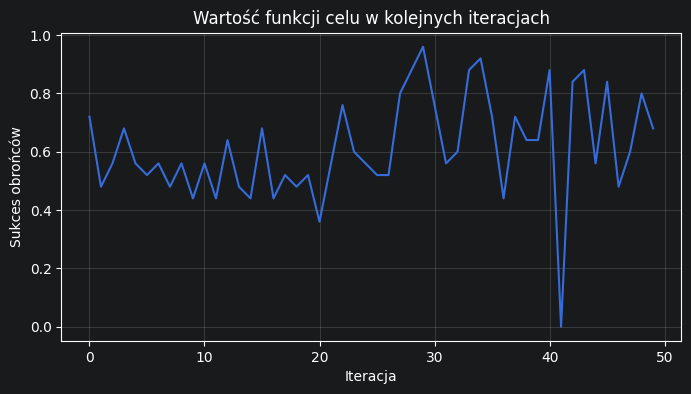

In [4]:
# %pip install plotly  # odkomentuj raz, aby włączyć interaktywny wykres 3D

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False


def reset_simulation():
    for defender in defenders:
        defender.reset_position()
    for offensive in offensives:
        offensive.reset_position()
    ball.reset()
    offensives[1].has_ball = True
    ball.owner = offensives[1]
    ball.follow_owner()


def run_single_simulation(params, max_steps=OPTIMIZATION_STEPS):
    reset_simulation()
    for _ in range(max_steps):
        if not simulate_step(params):
            return isinstance(ball.owner, DefensivePlayer)
    return False


def simulate_multiple_times(
    num_simulations=50,
    params=None,
    max_steps=OPTIMIZATION_STEPS,
):
    if params is None:
        params = DEFAULT_FORCE_PARAMS
    defender_wins = sum(run_single_simulation(params, max_steps) for _ in range(num_simulations))
    return defender_wins / num_simulations


def clip_params(k_pos, k_opp, k_team, lower=0.1, upper=10.0):
    return (
        float(np.clip(k_pos, lower, upper)),
        float(np.clip(k_opp, lower, upper)),
        float(np.clip(k_team, lower, upper)),
    )


def estimate_gradient(params, num_simulations, max_steps, delta=0.5):
    base_value = simulate_multiple_times(num_simulations, params, max_steps)
    base_values = (params.k_pos, params.k_opp, params.k_team)
    gradients = []
    for index in range(3):
        plus_values = list(base_values)
        minus_values = list(base_values)
        plus_values[index] += delta
        minus_values[index] -= delta
        plus_params = ForceParams(*clip_params(*plus_values))
        minus_params = ForceParams(*clip_params(*minus_values))
        plus_value = simulate_multiple_times(num_simulations, plus_params, max_steps)
        minus_value = simulate_multiple_times(num_simulations, minus_params, max_steps)
        gradients.append((plus_value - minus_value) / (2 * delta))
    return base_value, np.array(gradients, dtype=float)


def gradient_ascent(
    num_simulations=50,
    grad_simulations=30,
    alpha=0.25,
    max_iters=50,
    param_delta=0.5,
    decay_rate=0.995,
):
    k_pos, k_opp, k_team = DEFAULT_FORCE_PARAMS.k_pos, DEFAULT_FORCE_PARAMS.k_opp, DEFAULT_FORCE_PARAMS.k_team
    results = []
    best_params = ForceParams(k_pos, k_opp, k_team)
    best_value = 0.0

    for iteration in range(max_iters):
        params = ForceParams(*clip_params(k_pos, k_opp, k_team))
        current_value, gradient = estimate_gradient(
            params,
            num_simulations=grad_simulations,
            max_steps=OPTIMIZATION_STEPS,
            delta=param_delta,
        )
        results.append([params.k_pos, params.k_opp, params.k_team, current_value])

        if current_value > best_value:
            best_value = current_value
            best_params = params

        grad_norm = np.linalg.norm(gradient)
        if grad_norm > 0:
            gradient = gradient / grad_norm

        k_pos, k_opp, k_team = clip_params(
            k_pos + alpha * gradient[0],
            k_opp + alpha * gradient[1],
            k_team + alpha * gradient[2],
        )
        alpha *= decay_rate

        print(
            f"Iteracja {iteration + 1}: "
            f"k_pos={k_pos:.4f}, k_opp={k_opp:.4f}, k_team={k_team:.4f}, "
            f"wartość={current_value:.4f}"
        )

    print(f"\nNajlepsza wartość funkcji celu: {best_value:.4f}")
    print(
        "Odpowiadające jej parametry: "
        f"k_pos={best_params.k_pos:.4f}, k_opp={best_params.k_opp:.4f}, k_team={best_params.k_team:.4f}"
    )
    return best_params, np.array(results)


optimal_params, results = gradient_ascent(
    num_simulations=50,
    grad_simulations=25,
    alpha=0.25,
    max_iters=50,
)

function_values = results[:, 3]

plt.figure(figsize=(8, 4))
plt.plot(function_values)
plt.title("Wartość funkcji celu w kolejnych iteracjach")
plt.xlabel("Iteracja")
plt.ylabel("Sukces obrońców")
plt.grid(True, alpha=0.3)
plt.show()


def plot_3d_heatmap(results, interactive=True):
    k_pos = results[:, 0]
    k_opp = results[:, 1]
    k_team = results[:, 2]
    values = results[:, 3]

    if interactive and HAS_PLOTLY:
        hover_text = [
            f"k_pos={pos:.2f}<br>k_opp={opp:.2f}<br>k_team={team:.2f}<br>wartość={value:.3f}"
            for pos, opp, team, value in zip(k_pos, k_opp, k_team, values)
        ]
        fig = go.Figure(
            data=[
                go.Scatter3d(
                    x=k_pos,
                    y=k_opp,
                    z=k_team,
                    mode="markers",
                    marker=dict(
                        size=7,
                        color=values,
                        colorscale="RdYlGn",
                        cmin=values.min(),
                        cmax=values.max(),
                        colorbar=dict(title="Sukces obrońców"),
                        line=dict(width=0.5, color="black"),
                    ),
                    text=hover_text,
                    hoverinfo="text",
                )
            ]
        )
        fig.update_layout(
            title="Przestrzeń parametrów (obróć: przeciągnij myszką, przybliż: scroll)",
            scene=dict(
                xaxis_title="k_pos",
                yaxis_title="k_opp",
                zaxis_title="k_team",
            ),
            width=950,
            height=750,
            margin=dict(l=0, r=0, b=0, t=40),
        )
        fig.show()
        return

    if interactive and not HAS_PLOTLY:
        print("Brak biblioteki plotly — używam statycznego wykresu matplotlib.")
        print("Aby włączyć interaktywność: pip install plotly")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    scatter = ax.scatter(k_pos, k_opp, k_team, c=values, cmap="RdYlGn", s=50, edgecolor="k")
    cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label("Wartość funkcji celu")
    ax.set_xlabel("k_pos")
    ax.set_ylabel("k_opp")
    ax.set_zlabel("k_team")
    plt.title("Przestrzeń parametrów z wartościami funkcji celu")
    plt.show()


plot_3d_heatmap(results, interactive=True)


## Wnioski

Najlepszy wynik funkcji celu wynosi **96,0%** skuteczności obrońców (\(f = 0{,}9600\)), osiągnięty dla parametrów:

- $(k_{\text{pos}} = 0{,}91)$ — umiarkowane dążenie do pozycji wyjściowej,
- $(k_{\text{opp}} = 6{,}81)$ — silna reakcja na napastnika z piłką,
- $(k_{\text{team}} = 0{,}42)$ — słabsze odpychanie od kolegów z drużyny.

W porównaniu z wartościami startowymi $(1{,}0,\ 5{,}0,\ 1{,}0)$ optymalizacja zwiększyła wagę siły przyciągania do przeciwnika i wyraźnie obniżyła siłę odpychania między obrońcami. Oznacza to, że w tym modelu skuteczniejsza jest agresywna presja na piłkę niż utrzymywanie dużych odległości między obrońcami — mogą oni zbliżać się do siebie, by szybciej zamykać atak.

Na wykresie wartości funkcji celu w kolejnych iteracjach widać wyraźne fluktuacje (np. spadek do 0% w iteracji 42.), co wynika z losowości symulacji (odbiór piłki, tackle, podania). Mimo szumu widać jednak trend poprawy: najlepsze wyniki $(> 0{,}80)$ pojawiają się głównie po ok. 28. iteracji, gdy $k_{\text{opp}}$ rośnie powyżej 6,5, a $k_{team}$ spada poniżej 0,5.

Interaktywny wykres 3D potwierdza, że punkty o wysokiej wartości funkcji celu koncentrują się w tym regionie parametrów — wyższe $k_{\text{opp}}$, niższe $k_{\text{team}}$ i umiarkowane $k_{\text{pos}}$.

Podsumowując, gradient ascent z numerycznie liczonym gradientem dobrze nadaje się do strojenia tego modelu, choć ze względu na losowość warto uruchamiać optymalizację wielokrotnie lub zwiększyć liczbę symulacji na iterację, by wyniki były stabilniejsze. Uzyskany zestaw parametrów podnosi skuteczność obrony z ok. 72% (iteracja początkowa) do 96% w najlepszym przebiegu.

## Źródła
- Odwrócona piramida. Historia taktyki piłkarskiej - Jonathan Wilson
- https://pl.wikipedia.org/wiki/Prawo_Hooke’a
- https://pl.wikipedia.org/wiki/Prawo_powszechnego_ciążenia
- https://pl.wikipedia.org/wiki/Prawo_Coulomba
- https://www.baeldung.com/cs/gradient-descent-vs-ascent
- https://en.wikipedia.org/wiki/Gradient_descent
- https://en.wikipedia.org/wiki/Boids